# Generating CDFs

Most distributions are discovered by being curious about the world. Someone watches a phenomenon unfold, asks what mechanism could generate it, and then recognizes the mathematical pattern. It's good to remember that math is discovered, not invented.

In each of the following parts, there is a description of a simulation. Each of these simulations generates one of the following distributions, along with its name in `scipy.stats`:

| Distribution | SciPy PDF/PMF                               | SciPy CDF                                   | Parameters                          |
| ------------ | ------------------------------------------- | ------------------------------------------- | ----------------------------------- |
| Beta         | `beta.pdf(x, a, b)`                         | `beta.cdf(x, a, b)`                         | $(a,b)$                             |
| Pareto       | `pareto.pdf(x, b, scale=xm)`                | `pareto.cdf(x, b, scale=xm)`                | shape $b$, minimum $x_m$ |
| Uniform      | `uniform.pdf(x, loc=a, scale=b-a)`          | `uniform.cdf(x, loc=a, scale=b-a)`          | lower $a$, upper $b$            |
| Lognormal    | `lognorm.pdf(x, s=sigma, scale=np.exp(mu))` | `lognorm.cdf(x, s=sigma, scale=np.exp(mu))` | $\log X\sim N(\mu,\sigma^2)$      |
| Normal       | `norm.pdf(x, loc=mu, scale=sigma)`          | `norm.cdf(x, loc=mu, scale=sigma)`          | $(\mu,\sigma)$                      |
| Exponential  | `expon.pdf(x, scale=1/lam)`                 | `expon.cdf(x, scale=1/lam)`                 |  $\lambda$                   |


For parts 1-8 below, program and run the described simulation, plot its distribution using the ECDF, and compare with the distributions above.

Which simulations generate which CDFs?

# **Pick four simulations to complete. You do not have to do all of them.**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma
import ipywidgets as widgets

**Q1.**

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?

The distribution is uniform as K increases with probability spread evenly over an interval.

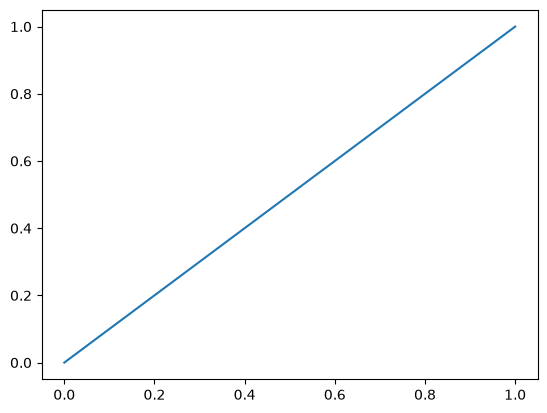

In [25]:
x = np.linspace(0, 1, 100)#Used Gen AI to help in figuring out grid set up,
plt.plot(x, stats.uniform.cdf(x, loc=0, scale=1))
plt.show()

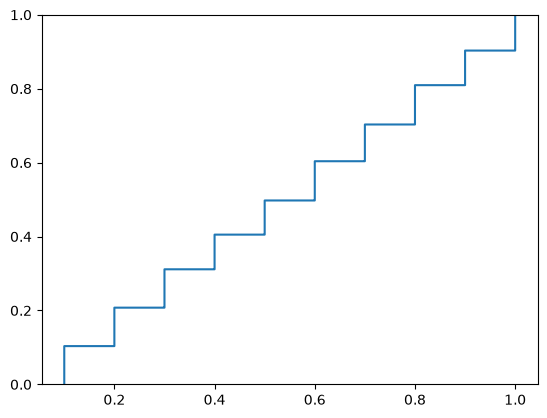

In [18]:
rng = np.random.default_rng(seed=100)

K = 10
n = 5_000

grid = np.arange(1, K + 1) / K
draws = rng.choice(grid, size=n)

plt.ecdf(draws)
plt.show()

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?


1
T. TDraw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

The distribution is normal.

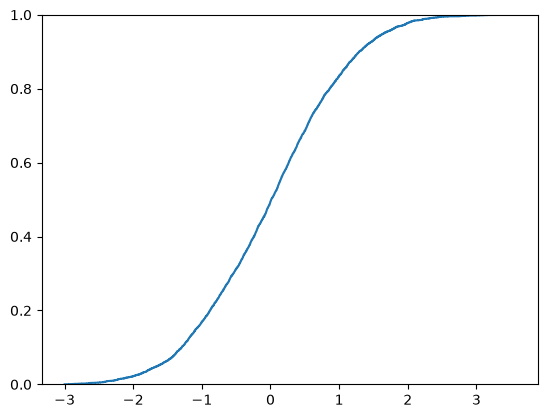

In [23]:
rng = np.random.default_rng(seed=100)

b = 5_000
n = 32

x = -np.sqrt(3) + 2*np.sqrt(3) * rng.random(size=(b, n)) #Used Gen AI in ChatGPT to refine this into computing mean and drawing values from specified uniform range.

result = x.mean(axis=1) * np.sqrt(n)

plt.ecdf(result)

**Q3.** 

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors. 

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?

As n increases, the distribution is normal.

6. How do the results change as you adjust $p$?

When p decreases, the graph has a left skew distribution. When p increases, the graph skews to the right.

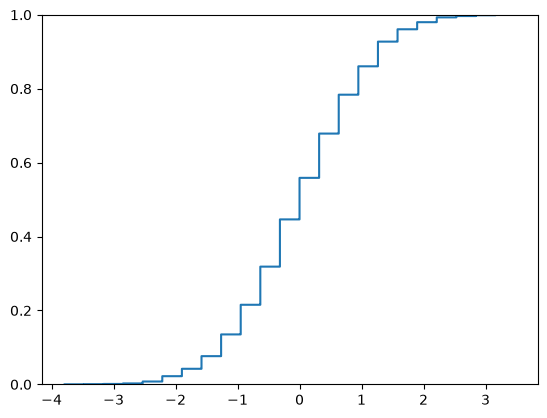

In [35]:
rng = np.random.default_rng(seed=100)

n = 40
p = 0.5

b = 5_000

flips = rng.binomial(1, p, size=(b, n)) #Got help of Gen AI to figure out the rng.binomial shortcut for binomial initial distribution data
heads = flips.sum(axis=1) #Actual acount of heads
result3 = (heads - n * p) / np.sqrt(n * p * (1 - p))

plt.ecdf(result3)
plt.show()

**Q4.** 

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?

This approaches exponential distribution.

5. How do the results change as you adjust $r$?

Increasing R leads to the curve growing quicker in ECDF before reaching a value of 1 on x-axis. Decreasing R leads to the curve taking longer to grow in ECDF.

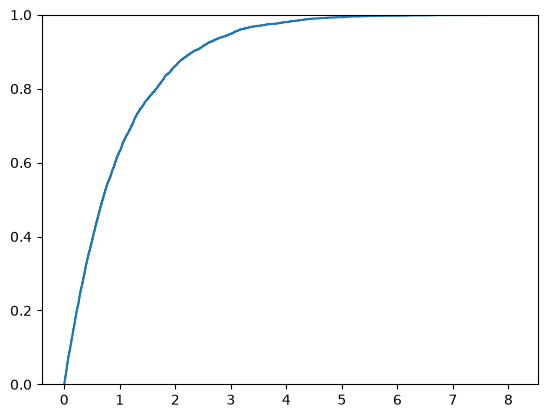

In [50]:
rng = np.random.default_rng(seed=100)
dt = 1e-3
r = 1
n = 5_000
result4 = [] #Store termination time for each simulation

for i in range(n): #Used loop to simulate 5000 times
    period = 1
    
    while rng.random() >= r * dt: #Loop continues if number is greater than r*dt
        period += 1
    
    result4.append(period * dt)
result4 = np.array(result4)

plt.ecdf(result4)